# Experiment 4: Token Rank Analysis

This notebook plots P(Gold | rank k) for multiple models across multiple datasets, showing the probability that a token retrieved at rank k comes from a gold (relevant) document.

In [26]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

import numpy as np

In [27]:
# Auto-discover all token rank data files
results_dir = Path("results/experiment_4_token_rank_analysis")

# Structure: {dataset: {model: data}}
all_data = defaultdict(dict)

for data_file in results_dir.glob("**/token_rank_data.json"):
    dataset = data_file.parent.parent.name
    model = data_file.parent.name
    
    with open(data_file) as f:
        data = json.load(f)
    
    all_data[dataset][model] = {
        "p_gold": np.array(data["p_gold"]),
        "total_queries": data["total_queries"],
        "total_tokens": data["total_tokens"],
    }

available_datasets = sorted(all_data.keys())
all_models = sorted(set(model for ds_data in all_data.values() for model in ds_data.keys()))

print(f"Found {len(available_datasets)} datasets with data:")
for ds in available_datasets:
    models_for_ds = sorted(all_data[ds].keys())
    print(f"  - {ds} ({len(models_for_ds)} models)")
print(f"\nFound {len(all_models)} unique models across all datasets:")
for model in all_models:
    print(f"  - {model}")

Found 3 datasets with data:
  - beir_fiqa_test (5 models)
  - beir_nfcorpus_test (5 models)
  - beir_trec-covid (4 models)

Found 5 unique models across all datasets:
  - experiment_1_contrastive_colbert_bs196_50k_ckpt50000
  - experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_bugfix_ckpt50000
  - experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_ckpt50000
  - lightonai_GTE-ModernColBERT-v1
  - robro612_xtr-base-en-pylate


In [28]:
# =============================================================================
# CONFIGURATION: Select which datasets to plot
# =============================================================================
# Set to None to plot all available datasets, or specify a list of dataset names
# Example: datasets_to_plot = ["beir_nfcorpus_test", "beir_scifact_test"]

datasets_to_plot = ["beir_nfcorpus_test", "beir_fiqa_test", "beir_trec-covid"]  # None = all available datasets

# Validate and set the datasets to use
if datasets_to_plot is None:
    selected_datasets = available_datasets
else:
    # Filter to only datasets that exist
    selected_datasets = [ds for ds in datasets_to_plot if ds in available_datasets]
    missing = [ds for ds in datasets_to_plot if ds not in available_datasets]
    if missing:
        print(f"Warning: The following datasets were requested but not found: {missing}")

print(f"Datasets selected for plotting ({len(selected_datasets)}):")
for ds in selected_datasets:
    print(f"  - {ds}")

Datasets selected for plotting (3):
  - beir_nfcorpus_test
  - beir_fiqa_test
  - beir_trec-covid


In [29]:
all_models

['experiment_1_contrastive_colbert_bs196_50k_ckpt50000',
 'experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_bugfix_ckpt50000',
 'experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_ckpt50000',
 'lightonai_GTE-ModernColBERT-v1',
 'robro612_xtr-base-en-pylate']

In [30]:
# Create display names for models (shorten long paths)
MODEL_DISPLAY_NAMES = {
    'experiment_1_contrastive_colbert_bs196_50k_ckpt50000' : 'ColBERT',
    'experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_bugfix_ckpt50000' : 'XTR (bugfix)',
    'experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_ckpt50000' : 'XTR',
    'lightonai_GTE-ModernColBERT-v1' : 'GTE-ModernColBERT',
    'robro612_xtr-base-en-pylate' : 'Google XTR'
}

all_models = list(MODEL_DISPLAY_NAMES.keys())

def get_display_name(model_name: str) -> str:
    return MODEL_DISPLAY_NAMES.get(model_name, model_name)

def get_dataset_display_name(dataset_name: str) -> str:
    """Convert dataset slug to display name."""
    return dataset_name

In [31]:
all_models

['experiment_1_contrastive_colbert_bs196_50k_ckpt50000',
 'experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_bugfix_ckpt50000',
 'experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_ckpt50000',
 'lightonai_GTE-ModernColBERT-v1',
 'robro612_xtr-base-en-pylate']

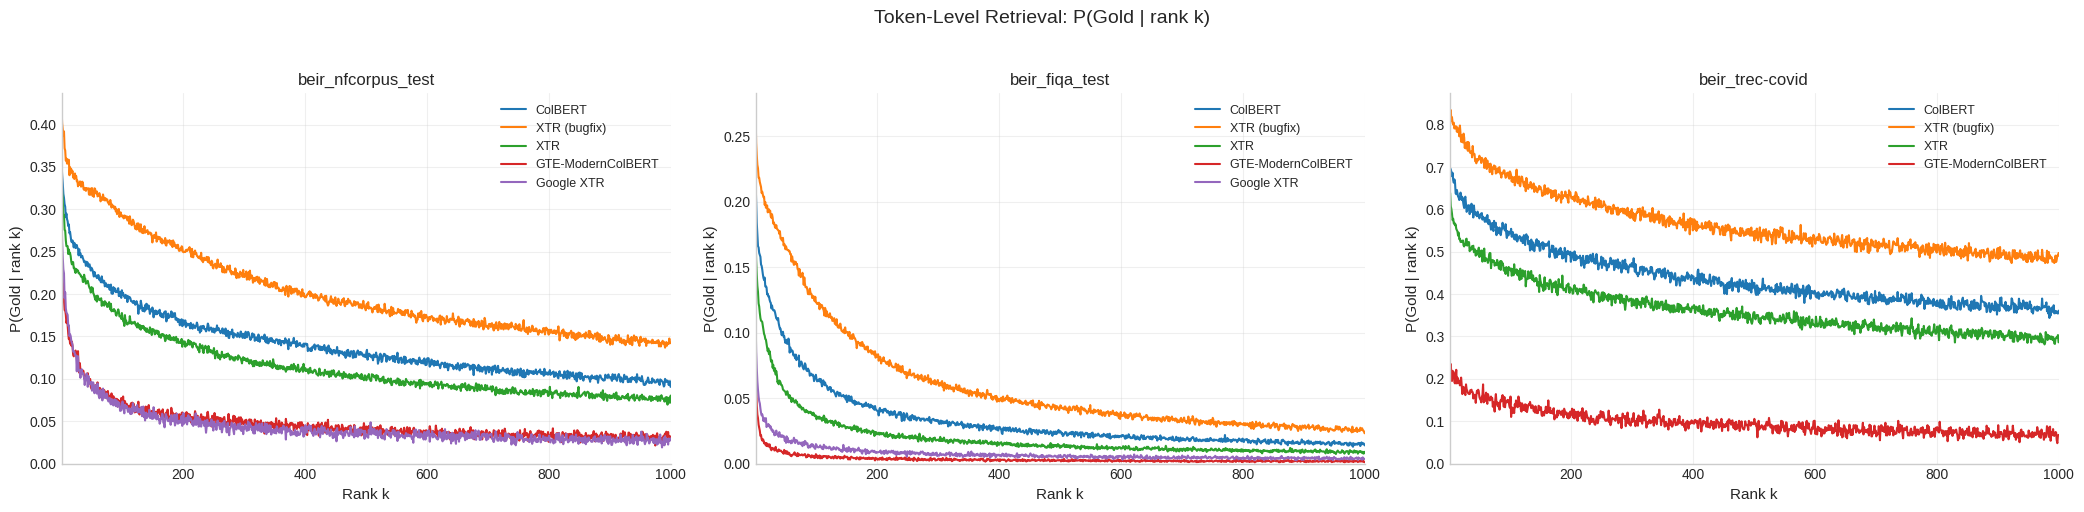

In [38]:
# Plot P(Gold | rank k) for all models across selected datasets
max_rank = 1000  # Only show first 1000 ranks

n_datasets = len(selected_datasets)
n_cols = min(3, n_datasets)
n_rows = (n_datasets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), squeeze=False)
axes = axes.flatten()

colors = plt.cm.tab10.colors

# Create consistent color mapping for models across all plots
model_colors = {model: colors[i % len(colors)] for i, model in enumerate(all_models)}

for idx, dataset in enumerate(selected_datasets):
    ax = axes[idx]
    ds_data = all_data[dataset]
    
    for model in sorted(ds_data.keys()):
        data = ds_data[model]
        p_gold = data["p_gold"][:max_rank]
        ranks = np.arange(1, len(p_gold) + 1)  # 1-indexed ranks
        display_name = MODEL_DISPLAY_NAMES.get(model, model)
        ax.plot(ranks, p_gold, linewidth=1.5, label=display_name, color=model_colors[model])
    
    ax.set_xlabel("Rank k", fontsize=11)
    ax.set_ylabel("P(Gold | rank k)", fontsize=11)
    ax.set_title(get_dataset_display_name(dataset), fontsize=12)
    ax.set_xlim(1, max_rank)
    ax.set_ylim(0.0)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Token-Level Retrieval: P(Gold | rank k)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/p_gold_at_rank_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
# Print summary statistics for all models and selected datasets
print("Summary: P(Gold | rank k) at key ranks")
print("=" * 80)

for dataset in selected_datasets:
    print(f"\n{get_dataset_display_name(dataset)}")
    print("-" * 80)
    print(f"{'Model':<35} {'Rank 1':>10} {'Rank 10':>10} {'Rank 100':>10} {'Rank 1000':>10}")
    print("-" * 80)
    
    for model in sorted(all_data[dataset].keys()):
        data = all_data[dataset][model]
        p_gold = data["p_gold"]
        r1 = p_gold[0] if len(p_gold) > 0 else 0
        r10 = p_gold[9] if len(p_gold) > 9 else 0
        r100 = p_gold[99] if len(p_gold) > 99 else 0
        r1000 = p_gold[999] if len(p_gold) > 999 else 0
        display_name = get_display_name(model)
        print(f"{display_name:<35} {r1:>10.3f} {r10:>10.3f} {r100:>10.3f} {r1000:>10.3f}")

Summary: P(Gold | rank k) at key ranks

beir_nfcorpus_test
--------------------------------------------------------------------------------
Model                                   Rank 1    Rank 10   Rank 100  Rank 1000
--------------------------------------------------------------------------------
ColBERT                                  0.353      0.288      0.205      0.091
XTR (bugfix)                             0.417      0.354      0.292      0.143
XTR                                      0.342      0.256      0.178      0.080
GTE-ModernColBERT                        0.245      0.169      0.073      0.032
Google XTR                               0.291      0.177      0.069      0.030

beir_fiqa_test
--------------------------------------------------------------------------------
Model                                   Rank 1    Rank 10   Rank 100  Rank 1000
--------------------------------------------------------------------------------
ColBERT                                  